In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
import math

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


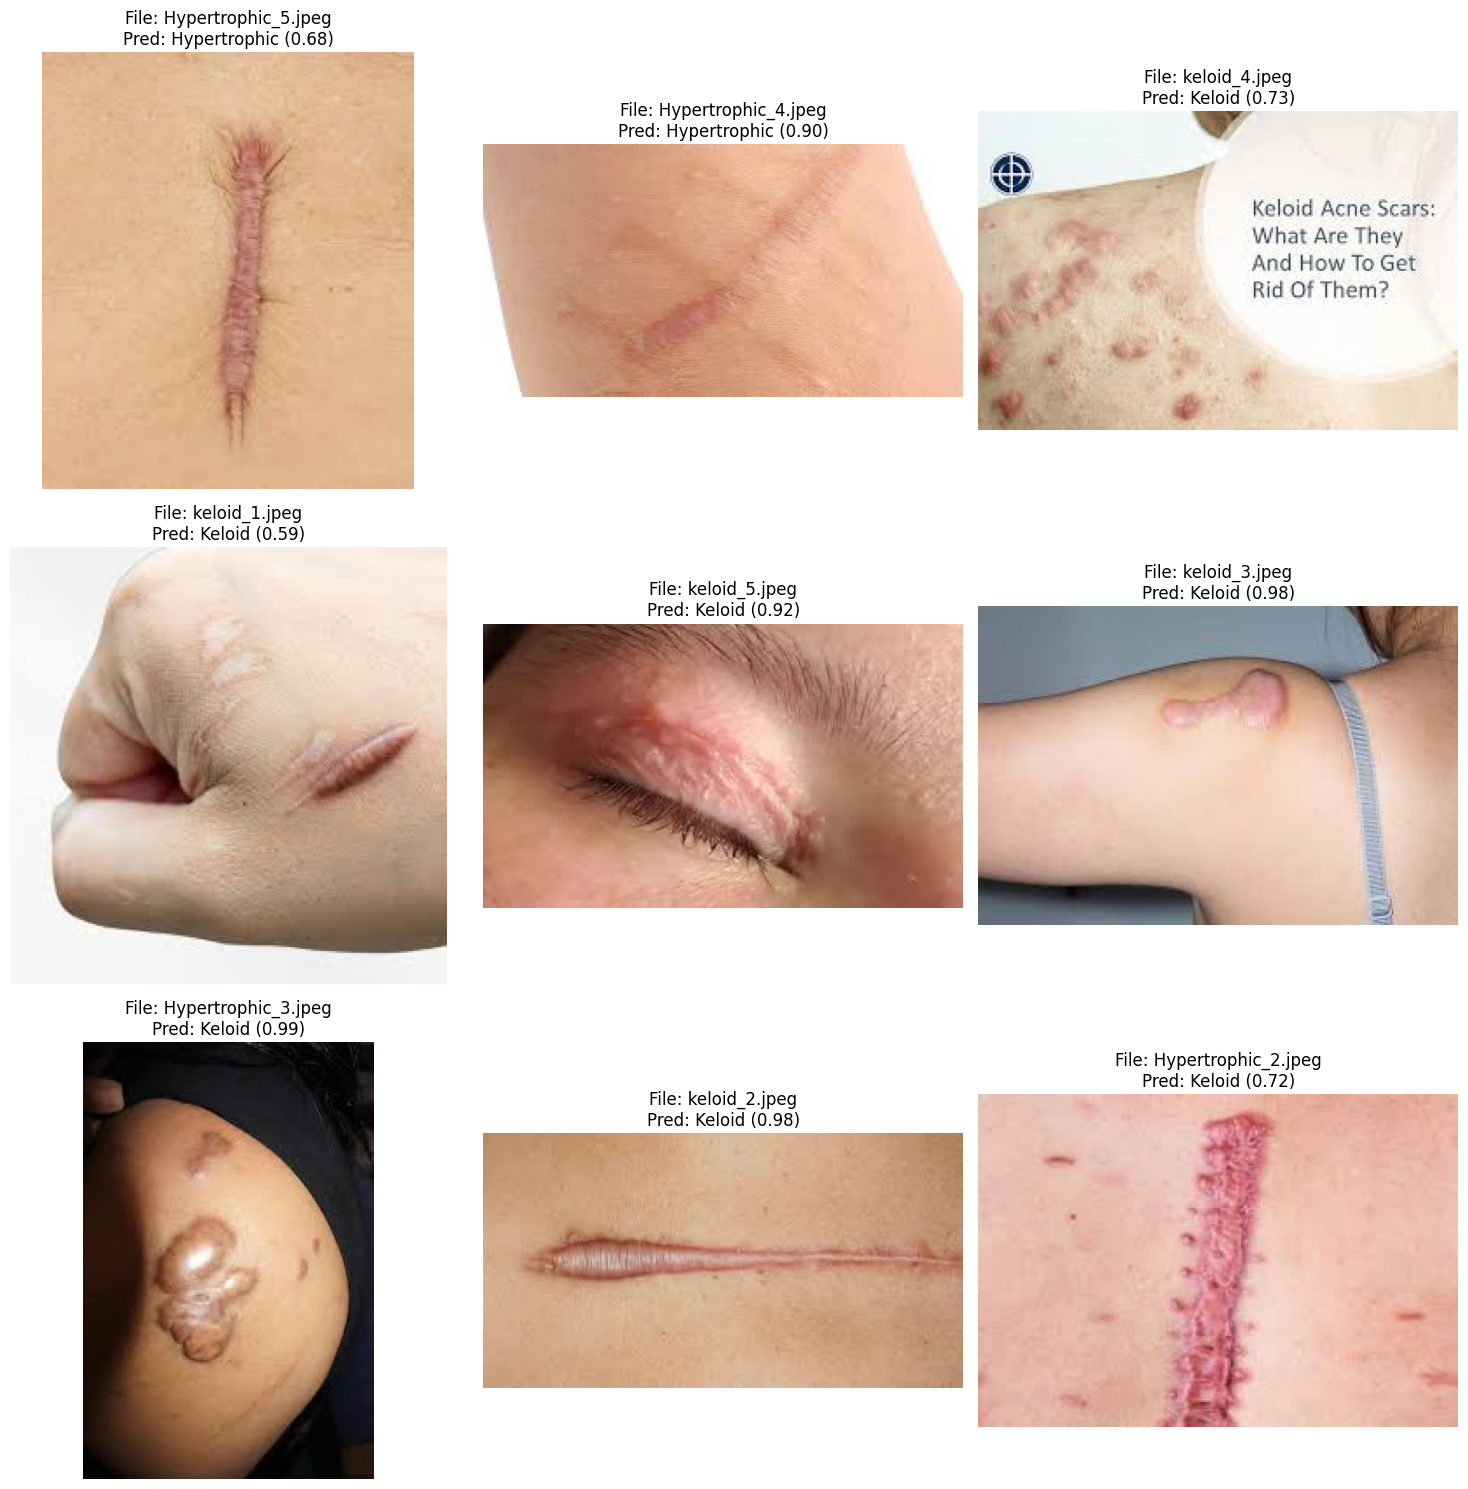

In [4]:
interpreter = tf.lite.Interpreter(model_path="/content/SCAR.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_shape = input_details[0]['shape']
height, width = input_shape[1], input_shape[2]

image_dir = '/content/Inference Asset'
image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
num_images = len(image_files)

class_names = ['Hypertrophic', 'Keloid']

cols = 3
rows = math.ceil(num_images / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()

for i, image_file in enumerate(image_files):
    img_path = os.path.join(image_dir, image_file)

    img_raw = Image.open(img_path).convert('RGB')
    img_resized = img_raw.resize((width, height))
    input_data = np.expand_dims(img_resized, axis=0)

    if input_details[0]['dtype'] == np.float32:
        input_data = (np.float32(input_data) - 127.5) / 127.5

    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])

    pred_idx = np.argmax(output_data)
    pred_label = class_names[pred_idx] if pred_idx < len(class_names) else f"Class {pred_idx}"
    confidence = output_data[0][pred_idx]

    axes[i].imshow(img_raw)
    axes[i].set_title(f"File: {image_file}\nPred: {pred_label} ({confidence:.2f})")
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## **Inference Test Result**
Correct Answer: 7 \
Wrong Answer: 2